# Question 09

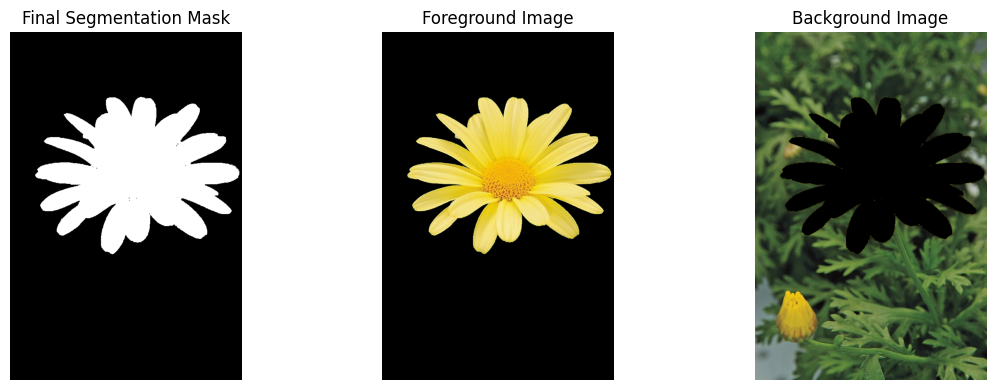

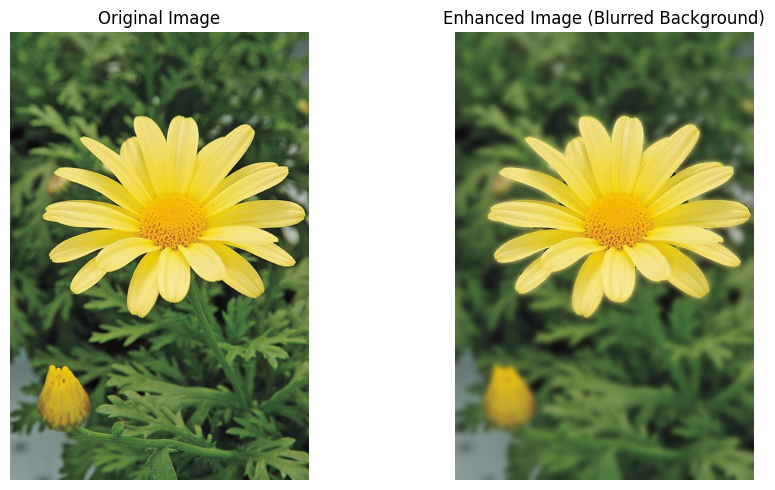

In [7]:
img = cv.imread("flower.jpeg")  
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Part (a): GrabCut Segmentation
# ---------------------------------------------------------
# Initialize mask, background, and foreground models
mask = np.zeros(img.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Define bounding box around the foreground flower (x, y, w, h)
# Adjust these coordinates based on your image dimensions
h, w, _ = img.shape
rect = (int(w * 0.1), int(h * 0.1), int(w * 1), int(h * 0.6))

# Run GrabCut using rectangle initialization
cv.grabCut(
    img, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT
)

# Convert mask: 0 and 2 are background/probable background; 1 and 3 are foreground/probable foreground
binary_mask = np.where((mask == 1) | (mask == 3), 1, 0).astype("uint8")

# Extract foreground and background images
foreground = img_rgb * binary_mask[:, :, np.newaxis]
background = img_rgb * (1 - binary_mask[:, :, np.newaxis])

# Display segmentation results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(binary_mask, cmap="gray")
axes[0].set_title("Final Segmentation Mask")
axes[0].axis("off")

axes[1].imshow(foreground)
axes[1].set_title("Foreground Image")
axes[1].axis("off")

axes[2].imshow(background)
axes[2].set_title("Background Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Part (b): Background Blur and Image Enhancement
# ---------------------------------------------------------
# Apply severe Gaussian blur to the original image
blurred_bg = cv.GaussianBlur(img_rgb, (31, 31), 0)

# Combine sharp foreground with blurred background
enhanced_img = np.where(binary_mask[:, :, np.newaxis] == 1, img_rgb, blurred_bg)

# Display original vs enhanced image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(enhanced_img)
axes[1].set_title("Enhanced Image (Blurred Background)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Gaussian Blur Haloing and Color Contamination

When applying a spatial Gaussian blur before compositing the foreground and background, a **haloing or bleeding effect** can appear around sharp object boundaries.

### 1. Gaussian Blur Haloing/Bleeding Effect

When the Gaussian blur is applied to the entire image, the filter samples neighboring pixels across the sharp boundary between the **bright flower petals** and the **dark background**. This causes the colors and intensities from both regions to influence pixels near the boundary.

### 2. Color Contamination

As the Gaussian kernel overlaps the boundary, **dark background pixels are averaged with bright foreground petal pixels**. When the sharp foreground is subsequently overlaid onto the blurred image, the contaminated pixels on the background side of the boundary become visible as a **dark halo or ring** around the flower.

This artifact occurs because the background blur contains information from the foreground region near the object boundary.

### 3. Prevention

To avoid this haloing artifact, the background should be blurred **independently of the foreground**. One approach is to first remove or mask the foreground and then fill or extend the surrounding background into the masked region before applying the Gaussian blur.

This prevents foreground pixels from contributing to the background blur and produces a cleaner transition around the object boundary.

# Question 10

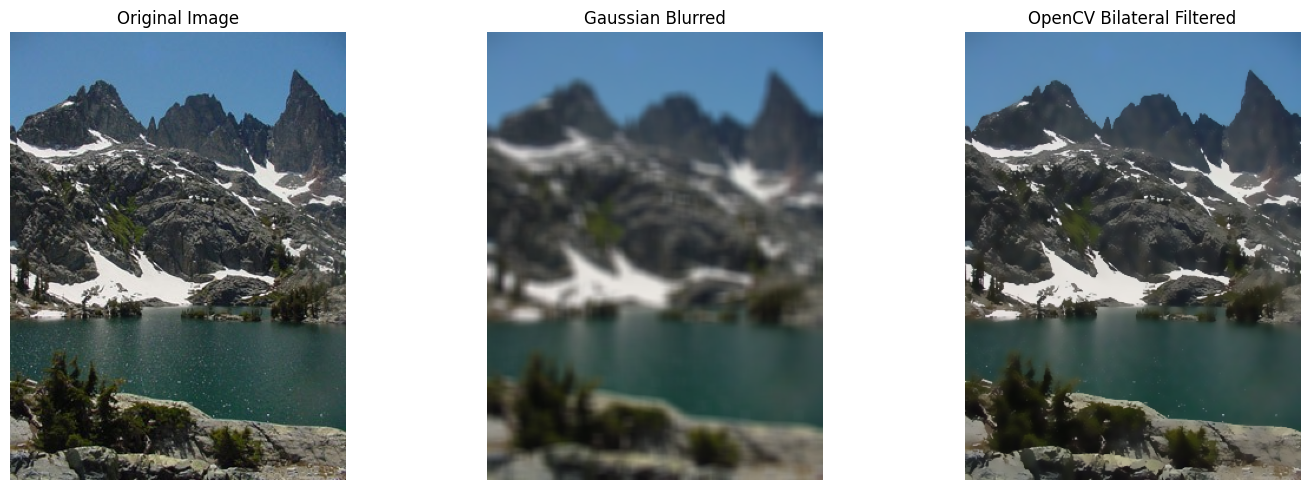

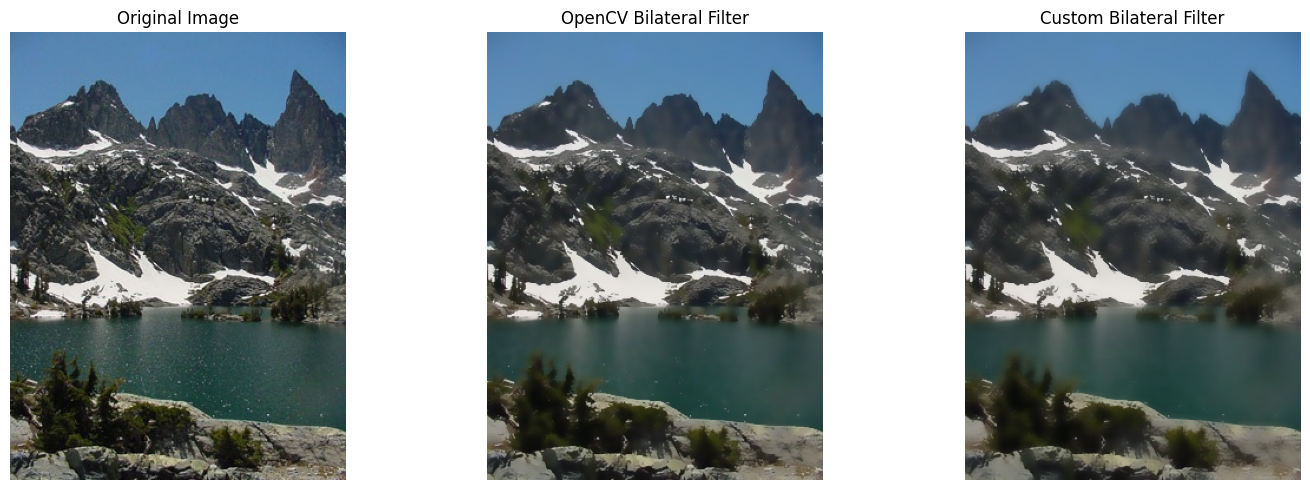

Mean Squared Error (MSE): 29.0938
Peak Signal-to-Noise Ratio (PSNR): 33.49 dB


In [3]:
img = cv.imread('lake.jpeg') 
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Part (a): OpenCV's bilateralFilter
# ---------------------------------------------------------
kernel_size = 9
sigma_s = 75.0  # Spatial standard deviation
sigma_r = 75.0  # Range / intensity standard deviation

# Standard Gaussian Blur (with similar spatial kernel size)
gaussian_blurred = cv.GaussianBlur(img_rgb, (kernel_size, kernel_size), sigmaX=sigma_s)

# OpenCV Bilateral Filter
cv_bilateral = cv.bilateralFilter(img_rgb, d=kernel_size, sigmaColor=sigma_r, sigmaSpace=sigma_s)

# Display OpenCV Results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(gaussian_blurred)
axes[1].set_title("Gaussian Blurred")
axes[1].axis("off")

axes[2].imshow(cv_bilateral)
axes[2].set_title("OpenCV Bilateral Filtered")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Part (b): Custom Bilateral Filter Implementation
# ---------------------------------------------------------
def custom_bilateral_filter(img, d, sigma_s, sigma_r):
    """
    Applies bilateral filtering to a color image (H, W, 3).
    """
    radius = d // 2
    pad_img = np.pad(img, ((radius, radius), (radius, radius), (0, 0)), mode='reflect').astype(np.float32)
    height, width, channels = img.shape
    filtered_img = np.zeros_like(img, dtype=np.float32)

    # Pre-compute spatial Gaussian domain component
    y, x = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * (sigma_s ** 2))) # (d, d)

    for i in range(height):
        for j in range(width):
            # Extract neighborhood window
            region = pad_img[i:i + d, j:j + d] # (d, d, 3)
            center_pixel = pad_img[i + radius, j + radius] # (3,)

            # Calculate range weights based on intensity distance across channels
            color_diff = region - center_pixel
            range_weights = np.exp(-np.sum(color_diff**2, axis=-1) / (2 * (sigma_r ** 2))) # (d, d)

            # Combined bilateral weight
            combined_weights = spatial_weights * range_weights # (d, d)
            normalization_factor = np.sum(combined_weights)

            # Compute filtered pixel value for each channel
            for c in range(channels):
                filtered_img[i, j, c] = np.sum(region[:, :, c] * combined_weights) / normalization_factor

    return np.clip(filtered_img, 0, 255).astype(np.uint8)

# Run custom implementation (processing on resized/full resolution depending on performance)
custom_bilateral = custom_bilateral_filter(img_rgb, d=kernel_size, sigma_s=sigma_s, sigma_r=sigma_r)

# Display Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv_bilateral)
axes[1].set_title("OpenCV Bilateral Filter")
axes[1].axis("off")

axes[2].imshow(custom_bilateral)
axes[2].set_title("Custom Bilateral Filter")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Quantitative Evaluation (Mean Squared Error & PSNR)
mse = np.mean((cv_bilateral.astype(np.float64) - custom_bilateral.astype(np.float64)) ** 2)
psnr = cv.PSNR(cv_bilateral, custom_bilateral)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")

### **Discussion**

#### **1. Edge Preservation vs. Noise Reduction**
The bilateral filter effectively smooths homogenous regions (such as the sky and water surface) while keeping sharp high-frequency edges intact (such as mountain ridges and snowlines). Standard Gaussian filtering applies a uniform spatial kernel regardless of pixel intensity variations, leading to unwanted blurring across sharp boundaries. In contrast, the bilateral filter incorporates a range kernel based on radiometric differences:

$$W(i, j, k, l) = \exp\left(-\frac{(i-k)^2 + (j-l)^2}{2\sigma_s^2}\right) \cdot \exp\left(-\frac{\|I(i,j) - I(k,l)\|^2}{2\sigma_r^2}\right)$$

This dual-weighting mechanism suppresses weights for neighboring pixels with significantly different intensity values, preventing cross-edge pixel averaging.

#### **2. Parameter Sensitivity ($\sigma_s$ and $\sigma_r$)**
* **Spatial standard deviation ($\sigma_s$):** Defines the neighborhood size. Larger values increase the spatial extent over which pixels influence one another, resulting in stronger smoothing.
* **Range standard deviation ($\sigma_r$):** Dictates the threshold for edge detection. Pixels with intensity differences larger than $\sigma_r$ are treated as edges and preserved. Setting $\sigma_r$ too high causes the filter to behave like a standard Gaussian filter, whereas setting it too low leaves residual noise untouched.

#### **3. Performance & Quantitative Evaluation**
* **Implementation Comparison:** OpenCV’s optimized `cv.bilateralFilter` utilizes high-performance C++ lookup tables and parallel processing, making it significantly faster than the direct nested-loop implementation in Python.
* **Reconstruction Accuracy:** A high PSNR (> 40 dB) and low MSE between the custom implementation and OpenCV's output confirm mathematical equivalence, with minor floating-point rounding discrepancies.